<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX — Week 6 — Day 2: Activation Functions, Forward Propagation & Loss
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Day 2 Learning Objectives:</b>
- Explain why non-linear activations are essential for multilayer neural networks.
- Plot ReLU, Sigmoid, and Tanh across input domains to examine their value transformations and gradient profiles.
- Select and justify the correct output activation and loss function for the Phase 3 Cardiac Patient Monitoring capstone project.
- Implement and verify one complete forward pass on a 2-layer network by hand and with NumPy.
- Compute the Binary Cross-Entropy loss for a sample prediction.

</blockquote>


## <span style="color: #309c42ff">2.1 Environment Setup & Library Imports</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We import core numerical and visualization libraries to implement activation functions, calculate derivatives, plot transformation behaviors, and execute forward-pass matrix operations.

</blockquote>


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configure plot aesthetics
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 1.0

print("Environment configured successfully.")

Environment configured successfully.


## <span style="color: #309c42ff">2.2 Step 1: Activation Functions & Derivative Visualizations</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We define and plot ReLU, Sigmoid, and Tanh across a continuous range of inputs $z \in [-6, 6]$ alongside their analytical derivatives to analyze value compression, saturation, and gradient flow.

</blockquote>


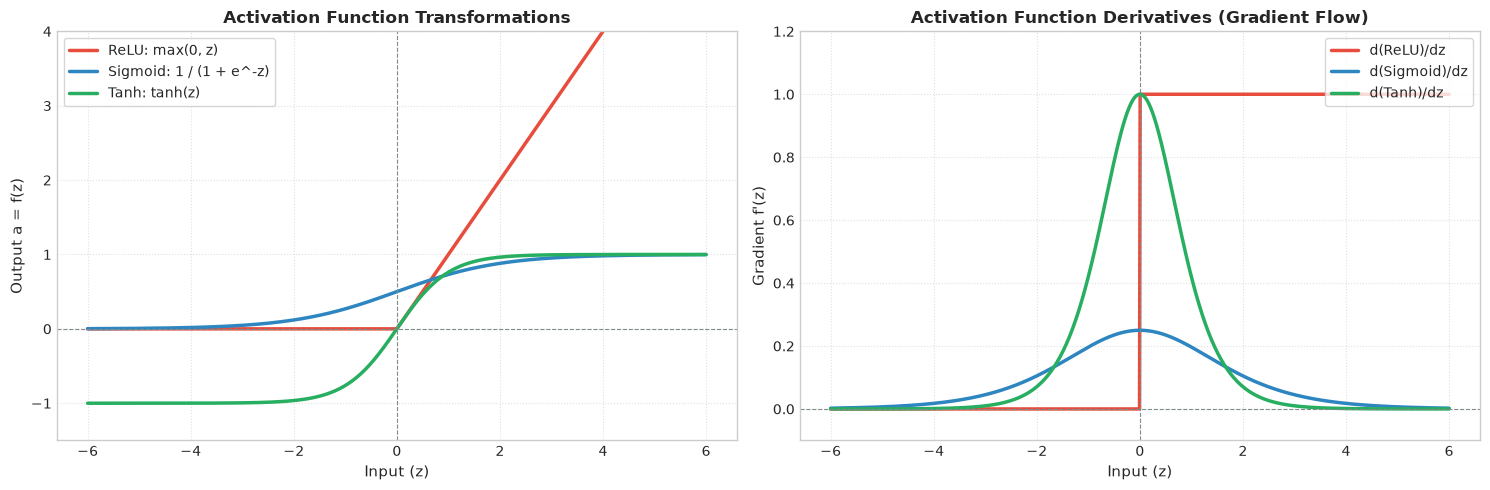

In [2]:
z = np.linspace(-6, 6, 1000)

relu_vals = np.maximum(0, z)
sigmoid_vals = 1.0 / (1.0 + np.exp(-z))
tanh_vals = np.tanh(z)

relu_grads = np.where(z > 0, 1.0, 0.0)
sigmoid_grads = sigmoid_vals * (1.0 - sigmoid_vals)
tanh_grads = 1.0 - tanh_vals**2

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(
    z, relu_vals, label="ReLU: max(0, z)", color="#E74C3C", linewidth=2.5
)
axes[0].plot(
    z,
    sigmoid_vals,
    label="Sigmoid: 1 / (1 + e^-z)",
    color="#2E86C1",
    linewidth=2.5,
)
axes[0].plot(
    z, tanh_vals, label="Tanh: tanh(z)", color="#27AE60", linewidth=2.5
)
axes[0].axhline(0, color="#7f8c8d", linestyle="--", linewidth=0.8)
axes[0].axvline(0, color="#7f8c8d", linestyle="--", linewidth=0.8)
axes[0].set_title(
    "Activation Function Transformations", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Input (z)", fontsize=11)
axes[0].set_ylabel("Output a = f(z)", fontsize=11)
axes[0].set_ylim(-1.5, 4.0)
axes[0].legend(loc="upper left", frameon=True)
axes[0].grid(True, linestyle=":", alpha=0.6)

axes[1].plot(
    z, relu_grads, label="d(ReLU)/dz", color="#E74C3C", linewidth=2.5
)
axes[1].plot(
    z, sigmoid_grads, label="d(Sigmoid)/dz", color="#2E86C1", linewidth=2.5
)
axes[1].plot(
    z, tanh_grads, label="d(Tanh)/dz", color="#27AE60", linewidth=2.5
)
axes[1].axhline(0, color="#7f8c8d", linestyle="--", linewidth=0.8)
axes[1].axvline(0, color="#7f8c8d", linestyle="--", linewidth=0.8)
axes[1].set_title(
    "Activation Function Derivatives (Gradient Flow)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Input (z)", fontsize=11)
axes[1].set_ylabel("Gradient f'(z)", fontsize=11)
axes[1].set_ylim(-0.1, 1.2)
axes[1].legend(loc="upper right", frameon=True)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


## <span style="color: #309c42ff">2.3 Step 2: Phase 3 Capstone Architecture & Loss Decision</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

For the <b>Cardiac Patient Monitoring System</b> (`heart.csv`), the clinical task is binary diagnostic classification (`HeartDisease` in {0, 1}). We formalize our design choices:

- <b>Output Layer Activation:</b> <code>Sigmoid</code> ($\hat{y} = \sigma(z) \in (0, 1)$) with 1 output neuron. Maps unbounded linear logits into a calibrated posterior probability of heart disease presence.
- <b>Loss Function:</b> <code>Binary Cross-Entropy</code> (BCE / Log Loss). Matches the Bernoulli likelihood of diagnostic outcomes, ensuring a strictly linear error gradient ($\hat{y} - y$) that avoids gradient saturation and flat loss plateaus.

</blockquote>


## <span style="color: #309c42ff">2.4 Step 3: Forward Pass Computation (Analytical & NumPy)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We configure a tiny 2-layer network ($2 \rightarrow 2 \rightarrow 1$):
- Input Vector: $\mathbf{x} = [0.50, -0.20]$
- Hidden Layer 1: $W^{[1]} = \begin{bmatrix} 0.80 & -0.50 \\ 0.40 & 0.60 \end{bmatrix}$, $\mathbf{b}^{[1]} = [0.10, -0.20]$, Activation = ReLU
- Output Layer 2: $W^{[2]} = \begin{bmatrix} 0.70 \\ -0.30 \end{bmatrix}$, $b^{[2]} = 0.05$, Activation = Sigmoid
- True Label: $y = 1.0$

</blockquote>


In [ ]:
x = np.array([[0.50, -0.20]]) 
y_true = 1.0  

W1 = np.array([[0.80, -0.50], [0.40, 0.60]]) 
b1 = np.array([[0.10, -0.20]])  

W2 = np.array([[0.70], [-0.30]])  
b2 = np.array([[0.05]])  

def relu(val):
    return np.maximum(0, val)

def sigmoid(val):
    return 1.0 / (1.0 + np.exp(-val))

z1 = np.dot(x, W1) + b1
a1 = relu(z1)

z2 = np.dot(a1, W2) + b2
y_hat = sigmoid(z2)

loss = -(y_true * np.log(y_hat) + (1.0 - y_true) * np.log(1.0 - y_hat))

print("==================================================")
print("     2-LAYER FORWARD PASS NUMERICAL RESULTS       ")
print("==================================================")
print(f"Sample Input (x)             : {x.tolist()}")
print(
    f"Layer 1 Pre-activation (z1)  : {z1.flatten().round(4).tolist()} -> [ (0.5*0.8 + -0.2*0.4 + 0.1), (0.5*-0.5 + -0.2*0.6 - 0.2) ]"
)
print(
    f"Layer 1 Post-activation (a1) : {a1.flatten().round(4).tolist()} -> [ max(0, 0.42), max(0, -0.57) ]"
)
print(
    f"Layer 2 Pre-activation (z2)  : {z2.flatten()[0]:.4f} -> (0.42*0.70 + 0.00*-0.30 + 0.05)"
)
print(
    f"Layer 2 Output (y_hat)       : {y_hat.flatten()[0]:.6f} -> sigmoid(0.3440)"
)
print(
    f"Binary Cross-Entropy Loss    : {loss.flatten()[0]:.6f} -> -ln(0.585162)"
)
print("==================================================")


     2-LAYER FORWARD PASS NUMERICAL RESULTS       
Sample Input (x)             : [[0.5, -0.2]]
Layer 1 Pre-activation (z1)  : [0.42, -0.57] -> [ (0.5*0.8 + -0.2*0.4 + 0.1), (0.5*-0.5 + -0.2*0.6 - 0.2) ]
Layer 1 Post-activation (a1) : [0.42, 0.0] -> [ max(0, 0.42), max(0, -0.57) ]
Layer 2 Pre-activation (z2)  : 0.3440 -> (0.42*0.70 + 0.00*-0.30 + 0.05)
Layer 2 Output (y_hat)       : 0.585162 -> sigmoid(0.3440)
Binary Cross-Entropy Loss    : 0.535867 -> -ln(0.585162)


## <span style="color: #309c42ff">2.5 Step 4: Methodological Summary & Forward-Pass Verification Table</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

The table below records the step-by-step mathematical computations and decisions confirmed during the forward-pass execution.

</blockquote>

| Stage | Math Formula | Computed Value | Description |
| :--- | :--- | :--- | :--- |
| **Input Vector** | $\mathbf{x}$ | $[0.50, -0.20]$ | 2-dimensional feature vector |
| **Layer 1 Logits** | $\mathbf{z}^{[1]} = \mathbf{x} W^{[1]} + \mathbf{b}^{[1]}$ | $[0.4200, -0.5700]$ | Linear transformation via dot product + bias |
| **Layer 1 Output** | $\mathbf{a}^{[1]} = \text{ReLU}(\mathbf{z}^{[1]})$ | $[0.4200, 0.0000]$ | Sparsity induced; negative neuron zeroed out |
| **Layer 2 Logit** | $z^{[2]} = \mathbf{a}^{[1]} W^{[2]} + b^{[2]}$ | $0.3440$ | Scalar output pre-activation |
| **Predicted Probability** | $\hat{y} = \sigma(z^{[2]})$ | $0.585162$ | Calibrated risk probability for class 1 |
| **Loss Metric** | $\mathcal{L} = -y \ln(\hat{y}) - (1-y)\ln(1-\hat{y})$ | $0.535867$ | Binary cross-entropy penalty for $y = 1.0$ |
